[구글 코랩(Colab)에서 실행하기](https://colab.research.google.com/github/lovedlim/bigdata_analyst_cert_v2/blob/main/part3/ch2/ch2_anova.ipynb)

# 1. 일원 분산 분석

### 1. 기본학습

In [4]:
import pandas as pd
df = pd.DataFrame({
    'A': [10.5, 11.3, 10.8, 9.6, 11.1, 10.2, 10.9, 11.4, 10.5, 10.3],
    'B': [11.9, 12.4, 12.1, 13.2, 12.5, 11.8, 12.2, 12.9, 12.4, 12.3],
    'C': [11.2, 11.7, 11.6, 10.9, 11.3, 11.1, 10.8, 11.5, 11.4, 11.0],
    'D': [9.8, 9.4, 9.1, 9.5, 9.6, 9.9, 9.2, 9.7, 9.3, 9.4]
})
print(df.head(5))

      A     B     C    D
0  10.5  11.9  11.2  9.8
1  11.3  12.4  11.7  9.4
2  10.8  12.1  11.6  9.1
3   9.6  13.2  10.9  9.5
4  11.1  12.5  11.3  9.6


(array([1., 1., 1., 2., 0., 1., 1., 1., 1., 1.]),
 array([9.1 , 9.18, 9.26, 9.34, 9.42, 9.5 , 9.58, 9.66, 9.74, 9.82, 9.9 ]),
 <BarContainer object of 10 artists>)

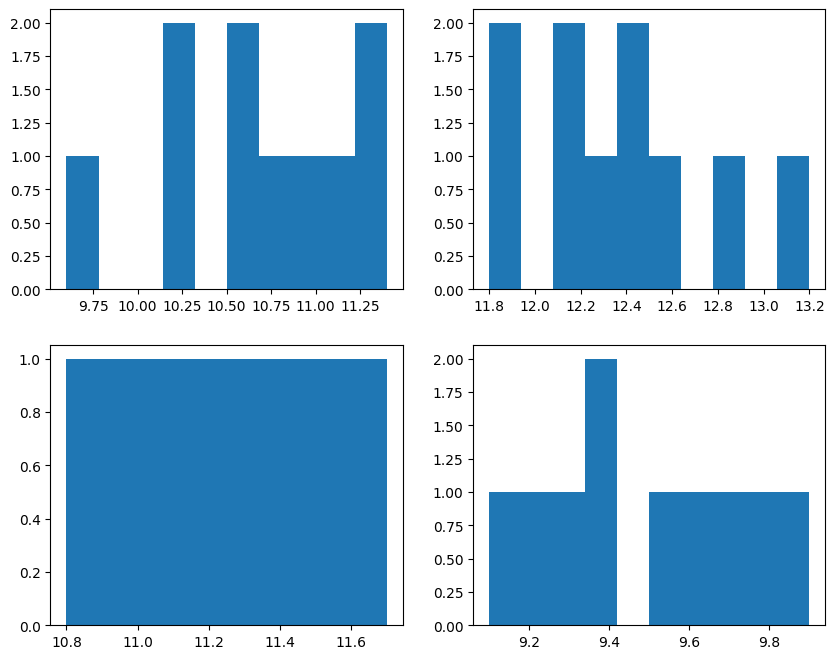

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,2, figsize=(10,8))
axes[0, 0].hist(df.A)
axes[0, 1].hist(df.B)
axes[1, 0].hist(df.C)
axes[1, 1].hist(df.D)

In [ ]:
from scipy import stats

print("=== 정규성 검정 ===")
print(stats.shapiro(df['A']))
print(stats.shapiro(df['B']))
print(stats.shapiro(df['C']))
print(stats.shapiro(df['D']))

print("\n === 등분산 검정 ===")
print(stats.levene(df['A'], df['B'], df['C'], df['D']))

print("\n === 일원 분산 분석 ===")
print(stats.f_oneway(df['A'], df['B'], df['C'], df['D']))

=== 정규성 검정 ===
ShapiroResult(statistic=0.9649055004119873, pvalue=0.840017557144165)
ShapiroResult(statistic=0.9468040466308594, pvalue=0.63086998462677)
ShapiroResult(statistic=0.9701647162437439, pvalue=0.8923683762550354)
ShapiroResult(statistic=0.9752339720726013, pvalue=0.9346861243247986)

 === 등분산 검정 ===
LeveneResult(statistic=1.9355354288758708, pvalue=0.14127835331346628)

 === 일원 분산 분석 ===
F_onewayResult(statistic=89.12613851177174, pvalue=1.0018381522523723e-16)


: 

In [ ]:
import pandas as pd
# df = pd.read_csv("fertilizer.csv")
df = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part3/ch2/fertilizer.csv")

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
model = ols('성장 ~ C(비료)', df).fit()
print(anova_lm(model))

# 이원 분산 분석

In [ ]:
import pandas as pd
# df = pd.read_csv("tree.csv")
df = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part3/ch2/tree.csv")
print(df.sample(10))

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('성장률 ~ 나무 + 비료 + 나무:비료', data=df).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('성장률 ~ C(나무) + C(비료) + C(나무):C(비료)', data=df).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

In [ ]:
print(format(6.600012e-10, '.11f'))
print(format(1.857612e-03, '.11f'))
print(format(2.157357e-01, '.11f'))

In [ ]:
model = ols('성장률 ~ C(나무) * C(비료)', data=df).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)